# 光学滤光片带通优化 — 四案例

对齐 Oghma 项目 [`01_hello_optical_filter`](../../oghma_projects/optical/01_hello_optical_filter) 与 [`01_optical_filter.ipynb`](01_optical_filter.ipynb) 的被动 TMM 膜系（air(100 nm) + layer0–9，出射半无限 layer9）。

**波长**：`REF["reflect_wl_nm"]`；**角度**：0–60°。

| Case | Cost | 目标 |
|------|------|------|
| 1 | `bandpass_filter` | 反射通带 400–650 nm 内高 R |
| 2 | `bandpass_filter` | 透射禁带 400–650 nm 内低 T |
| 3 | `minimize_reflectance_deviation` | 450–550 nm 内 R≈0.8 |
| 4 | `minimize_transmittance_deviation` | 450–550 nm 内 T≈0.2 |

运行前提：在 `build/` 打开；Oghma 项目与 materials root 可用。

In [ ]:
import copy
import os
import sys
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

import filmstack_optimization_utils as fos
from filmstack_visualizer import merge_filmstack_optimization_config
from oghma_core import (
    air_layer_thickness_um,
    filter_stack_layers,
    load_oghma_material_nk,
    load_oghma_optical_reference,
    load_oghma_project,
    passive_filter_stack_labels,
)
from filmstack_optimization_utils import Polarization, StackSpec


In [2]:
from oghma_core import OghmaProject, filter_stack_layers, preload_oghma_materials

def filter_project_material_paths(
    project: OghmaProject,
    *,
    exit_halfspace: str = "top_layer",
) -> list[str]:
    """Unique Oghma optical_material paths for a passive optical-filter stack."""
    stack = filter_stack_layers(project)
    paths = [layer.optical_material for layer in stack]
    if exit_halfspace == "top_layer" and stack:
        paths.append(stack[-1].optical_material)
    return list(dict.fromkeys(paths))





In [3]:
TOLERANCE = 0.70
OGHMA_PROJECT_DIR = REPO / "assets" / "oghma_projects" / "optical" / "01_hello_optical_filter"
PROJECT = load_oghma_project(OGHMA_PROJECT_DIR)
REF = load_oghma_optical_reference(PROJECT)
wl_um = np.asarray(REF["reflect_wl_um"], dtype=float)
WL_UM = wl_um
AIR_UM = air_layer_thickness_um(PROJECT)
POL = Polarization.TE

PASS_HIGH_R = 0.88
PASS_LOW_R = 0.08
STOP_LOW_T = 0.12
STOP_HIGH_T = 0.88
CASE3_R_TARGET = 0.8
CASE4_T_TARGET = 0.2

# merit 网格步长（越大 → cost 评估点数越少，优化越快）
MERIT_WL_STEP_WIDE_UM = 0.02   # Case 1/2: 400–650 nm
MERIT_WL_STEP_NARROW_UM = 0.02  # Case 3/4: 450–550 nm
MERIT_ANGLE_STEP_DEG = 10.0


def _filter_token(layer) -> str:
    return layer.name.split()[0].replace(":", "")


from oghma_core import passive_filter_formula_from_project, passive_filter_materials_db

FORMULA = passive_filter_formula_from_project(PROJECT, exit_halfspace="top_layer")
MATERIALS_DB = passive_filter_materials_db(PROJECT, exit_halfspace="top_layer")
FILTER_STACK = filter_stack_layers(PROJECT)
STACK_LABELS = passive_filter_stack_labels(PROJECT)
EXIT_HALFSPACE_LABEL = f"{FILTER_STACK[-1].name.split()[0]}(∞)"
_spec_preview = fos.stack_from_formula(FORMULA, MATERIALS_DB)

layer_bounds = []
for idx in _spec_preview.film_indices:
    if idx == 1:
        continue
    t0 = _spec_preview.thicknesses_um[idx]
    layer_bounds.append({
        "index": idx,
        "min": max(0.001, t0 * (1.0 - TOLERANCE)),
        "max": t0 * (1.0 + TOLERANCE),
    })

BASE_OPT_CONFIG = {
    "formula": FORMULA,
    "polarization": "UNPOLARIZED",
    "layer_bounds": layer_bounds,
    "thickness_min": 0.001,
    "thickness_max": 1.0,
    "optimizer": {
        "method": "L-BFGS-B",
        "options": {
            "maxiter": 60,
            "maxfun": 6000,
            "ftol": 1e-11,
            "gtol": 1e-9,
            "maxcor": 10,
            "maxls": 20,
            "disp": False,
        },
    },
    "multi_start": {"n_starts": 1, "seed": 7, "include_formula_x0": True},
    "dump": None,
    "verbose": True,
    "viz": {"show": ["convergence"]},
    "input": None,
}

from simulation_database_parser import get_simulation_database

get_simulation_database(init=True)
_OGHMA_MATERIALS = preload_oghma_materials(
    filter_project_material_paths(PROJECT, exit_halfspace="top_layer")
)
print(f"preloaded {len(_OGHMA_MATERIALS)} Oghma material tables via simulation_database")
print(f"λ: {wl_um[0]:.1f}–{wl_um[-1]:.1f} nm ({len(wl_um)} pts)")
print("formula:", FORMULA)
print("optimizable layers:", len(layer_bounds))

def _oghma_spec_from_result(result):
    return fos.stack_from_formula(result["FORMULA"], MATERIALS_DB)


fos._spec_from_result = _oghma_spec_from_result


preloaded 2 Oghma material tables from /mnt/c/Users/like/oghma_local/materials
λ: 303.7–1396.3 nm (150 pts)
formula: Air 0 air 0.10000 layer0 0.08300 layer1 0.12600 layer2 0.08300 layer3 0.12600 layer4 0.08300 layer5 0.12600 layer6 0.08300 layer7 0.12600 layer8 0.08300 layer9 0.12600 ExitLayer 0
optimizable layers: 10


In [4]:

def _rt_power(layers, angle_rad: float, wl_um: float):
    r_s, t_s, r_p, t_p = fos.get_r_t(layers, float(angle_rad), float(wl_um))
    return abs(r_s) ** 2, abs(t_s) ** 2, abs(r_p) ** 2, abs(t_p) ** 2


def _combine_polarization(R_s, T_s, R_p, T_p, pol: Polarization):
    if pol == Polarization.TE:
        return R_s, T_s
    if pol == Polarization.TM:
        return R_p, T_p
    return 0.5 * (R_s + R_p), 0.5 * (T_s + T_p)

def metric_spectrum(result, film_thicknesses_um, wl_um_grid: np.ndarray, metric: str = "reflectance") -> np.ndarray:
    spec = fos.stack_from_formula(result["FORMULA"], MATERIALS_DB)
    x = np.asarray(film_thicknesses_um, dtype=float)
    pol = Polarization(str(result["POLARIZATION"]).upper())
    out = np.zeros(len(wl_um_grid), dtype=float)
    for i, wl in enumerate(wl_um_grid):
        layers = fos.layers_from_x(spec, x)
        R_s, T_s, R_p, T_p = _rt_power(layers, 0.0, float(wl))
        R, T = _combine_polarization(R_s, T_s, R_p, T_p, pol)
        out[i] = R if metric == "reflectance" else T
    return out


def stack_thicknesses_nm(spec: StackSpec, film_thicknesses_um: np.ndarray) -> list[float]:
    thicknesses = list(spec.thicknesses_um)
    for idx, t in zip(spec.film_indices, film_thicknesses_um):
        thicknesses[idx] = float(t)
    return [t * 1000.0 for t in thicknesses]


def plot_filter_stack_barh(spec: StackSpec, film_thicknesses_um: np.ndarray, *, title: str):
    from filmstack_visualizer import plot_filmstack

    x = np.asarray(film_thicknesses_um, dtype=float)
    layers = fos.layers_from_x(spec, x)
    plot_filmstack(layers, title=title)


def plot_metric_1d_before_after_diff(x_nm, before, after, ylabel, title):
    diff = after - before
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(x_nm, before, label="before")
    axes[0].plot(x_nm, after, label="after")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x_nm, diff, color="C3")
    axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_xlabel("wavelength (nm)")
    axes[1].set_ylabel(f"Δ{ylabel}")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def print_summary(result):
    opt = result["OPT"]
    print(f"cost function: {result['COST_FUNCTION']['name']}")
    print(f"merit: {opt['merit_initial']:.6g} -> {opt['merit_final']:.6g}")
    print(f"success: {opt['success']}, message: {opt['message']}")


def _target_spectrum(wl_lo, wl_hi, n_wl, n_ang, *, band_metric: str, wide: bool):
    user_wls = np.linspace(wl_lo, wl_hi, n_wl)
    user_angles = np.linspace(0.0, 60.0, n_ang)
    if band_metric == "R":
        arr = np.full((n_ang, n_wl), PASS_LOW_R)
        for j, wl in enumerate(user_wls):
            in_band = (0.400 <= wl <= 0.650) if wide else (0.450 <= wl <= 0.550)
            if in_band:
                arr[:, j] = PASS_HIGH_R
        return user_wls, user_angles, arr
    arr = np.full((n_ang, n_wl), STOP_HIGH_T)
    for j, wl in enumerate(user_wls):
        in_band = (0.400 <= wl <= 0.650) if wide else (0.450 <= wl <= 0.550)
        if in_band:
            arr[:, j] = STOP_LOW_T
    return user_wls, user_angles, arr


def run_example(case_name: str, overrides: dict, *, metric: str):
    cfg = merge_filmstack_optimization_config(BASE_OPT_CONFIG, overrides)
    spec = fos.stack_from_formula(cfg["formula"], MATERIALS_DB)
    targets, target_wls, target_angles = fos.build_targets_from_cfg(cfg)
    pol = Polarization(str(cfg["polarization"]).upper())
    ctx = fos.make_objective_context(spec, targets, pol, cfg)
    cf = cfg["cost_function"]
    cost_fn = fos.load_filmstack_cost_function(cf["path"], cf["name"])
    x0 = np.array([spec.thicknesses_um[i] for i in spec.film_indices], dtype=float)
    merit_initial, _ = cost_fn(x0, ctx)
    opt_x, opt_result, merit_history, _ = fos._run_optimize(spec, ctx, cost_fn, cfg)
    result = fos.build_result_dict(
        cfg["formula"], spec, opt_x, targets, cf, pol, opt_result, merit_initial,
        cfg, merit_history, target_wls=target_wls, target_angles=target_angles,
    )
    opt = result["OPT"]
    cfg_viz = copy.deepcopy(cfg)
    cfg_viz.setdefault("viz", {})["show"] = ["convergence"]
    fos.run_filmstack_optimization_visualizations(result, cfg_viz, interactive=True)
    plot_filter_stack_barh(spec, opt["initial_thicknesses_um"], title=f"{case_name} — before")
    plot_filter_stack_barh(spec, opt["optimized_thicknesses_um"], title=f"{case_name} — after")
    before = metric_spectrum(result, opt["initial_thicknesses_um"], WL_UM, metric=metric)
    after = metric_spectrum(result, opt["optimized_thicknesses_um"], WL_UM, metric=metric)
    ylabel = "Reflectance R" if metric == "reflectance" else "Transmittance T"
    plot_metric_1d_before_after_diff(wl_um, before, after, ylabel, f"{case_name}: {ylabel} @ 0°")
    print_summary(result)
    return result


py_pipe log: /tmp/simulation_plot_data_061600/py_pipe_159863.log cmd: /home/like/repos/simulation/3rdparty/infrastructure/.venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /tmp/tmpttpydk5p.json --HistoryManager.hist_file=:memory:


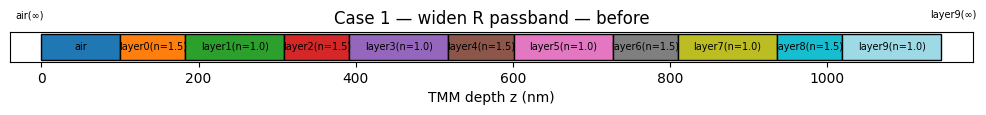

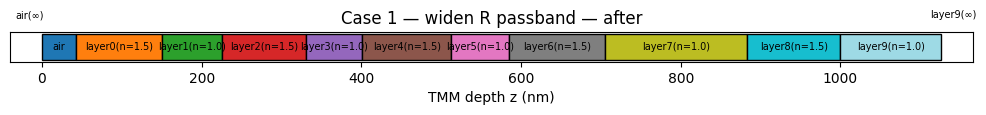

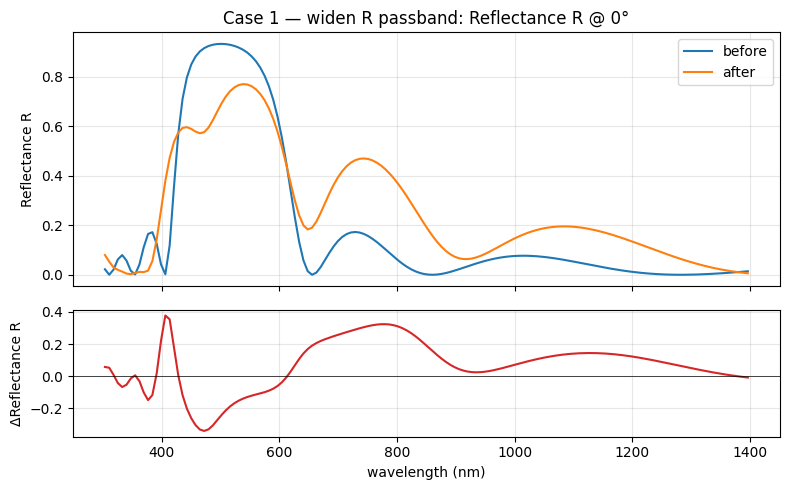

cost function: bandpass_filter
merit: 0.257719 -> 0.17324
success: False, message: ABNORMAL: 


In [5]:
# Case 1: widen reflectance passband 400–650 nm
_, _, R_user = _target_spectrum(0.40, 0.65, 5, 3, band_metric="R", wide=True)
result_case1 = run_example(
    "Case 1 — widen R passband",
    {
        "cost_function": {"path": "filmstack_optimization_utils.py", "name": "bandpass_filter"},
        "target_wl": [0.40, 0.65, MERIT_WL_STEP_WIDE_UM],
        "target_angle": [0, 60, MERIT_ANGLE_STEP_DEG],
        "R_target_spectrum": R_user.tolist(),
    },
    metric="reflectance",
)


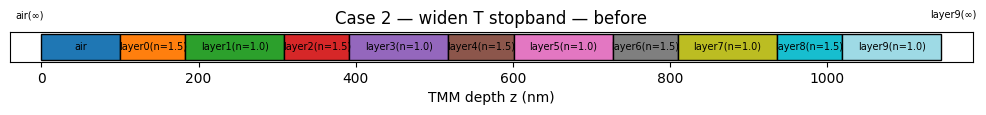

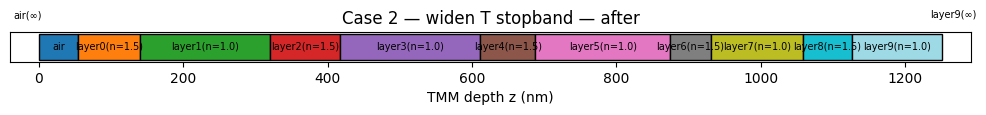

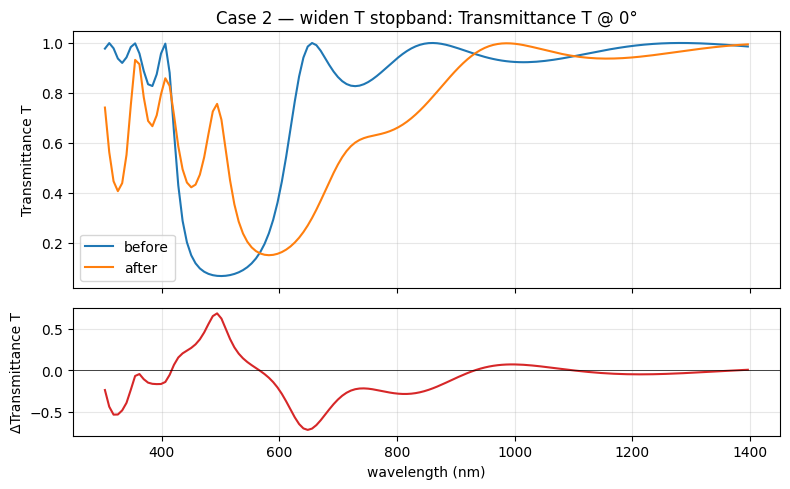

cost function: bandpass_filter
merit: 0.257163 -> 0.137426
success: False, message: ABNORMAL: 


In [6]:

# Case 2: widen transmittance stopband 400–650 nm
_, _, T_user = _target_spectrum(0.40, 0.65, 5, 3, band_metric="T", wide=True)
result_case2 = run_example(
    "Case 2 — widen T stopband",
    {
        "cost_function": {"path": "filmstack_optimization_utils.py", "name": "bandpass_filter"},
        "target_wl": [0.40, 0.65, MERIT_WL_STEP_WIDE_UM],
        "target_angle": [0, 60, MERIT_ANGLE_STEP_DEG],
        "T_target_spectrum": T_user.tolist(),
    },
    metric="transmittance",
)


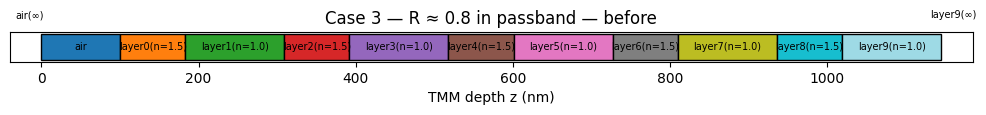

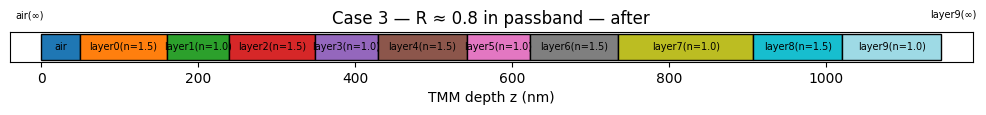

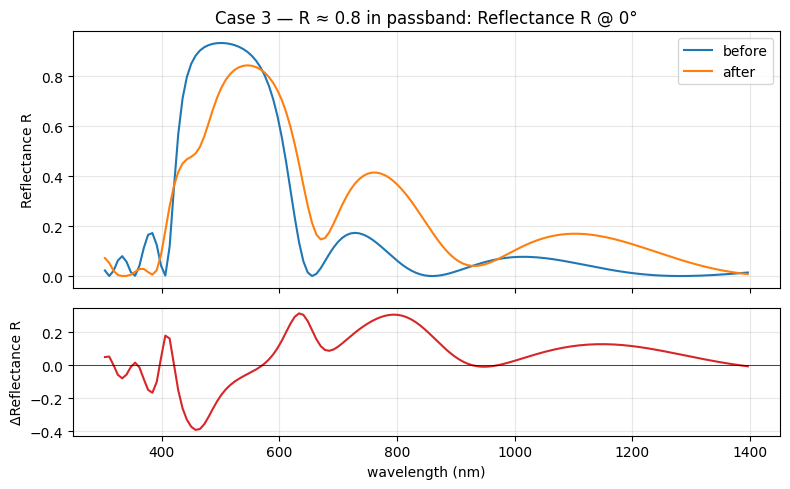

cost function: minimize_reflectance_deviation
merit: 0.108451 -> 0.0661784
success: False, message: ABNORMAL: 


In [7]:

# Case 3: R ≈ 0.8 in 450–550 nm
result_case3 = run_example(
    "Case 3 — R ≈ 0.8 in passband",
    {
        "cost_function": {"path": "filmstack_optimization_utils.py", "name": "minimize_reflectance_deviation"},
        "R_target": CASE3_R_TARGET,
        "target_wl": [0.45, 0.55, MERIT_WL_STEP_NARROW_UM],
        "target_angle": [0, 60, MERIT_ANGLE_STEP_DEG],
    },
    metric="reflectance",
)

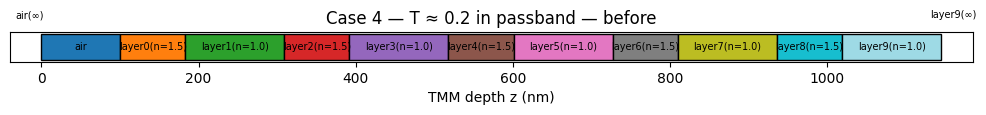

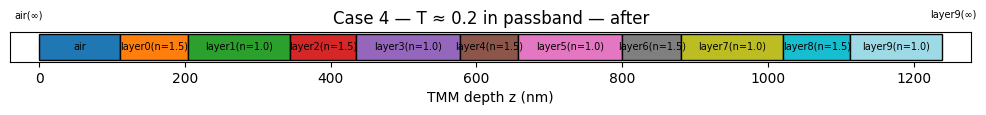

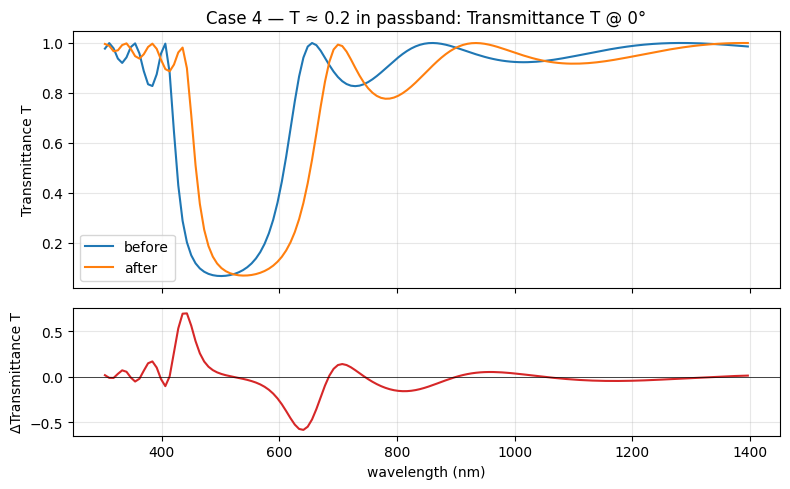

cost function: minimize_transmittance_deviation
merit: 0.108176 -> 0.0722719
success: False, message: ABNORMAL: 


In [8]:

# Case 4: T ≈ 0.2 in 450–550 nm
result_case4 = run_example(
    "Case 4 — T ≈ 0.2 in passband",
    {
        "cost_function": {"path": "filmstack_optimization_utils.py", "name": "minimize_transmittance_deviation"},
        "T_target": CASE4_T_TARGET,
        "target_wl": [0.45, 0.55, MERIT_WL_STEP_NARROW_UM],
        "target_angle": [0, 60, MERIT_ANGLE_STEP_DEG],
    },
    metric="transmittance",
)


In [9]:


print("\n=== Summary ===")
for label, res in (
    ("Case 1 bandpass R", result_case1),
    ("Case 2 bandpass T", result_case2),
    ("Case 3 R deviation", result_case3),
    ("Case 4 T deviation", result_case4),
):
    opt = res["OPT"]
    print(f"{label:22s}  merit {opt['merit_initial']:.4g} -> {opt['merit_final']:.4g}")


=== Summary ===
Case 1 bandpass R       merit 0.2577 -> 0.1732
Case 2 bandpass T       merit 0.2572 -> 0.1374
Case 3 R deviation      merit 0.1085 -> 0.06618
Case 4 T deviation      merit 0.1082 -> 0.07227
